# LSTM Delta Learning V2 - Interpolation Fix

## Changes from V1
- **Problem:** V1 showed staircase pattern (same state repeated for horizon steps)
- **Solution:** Linear interpolation between current and predicted next state

## V2 Fix
```python
# V1 (staircase):
for _ in range(horizon):
    predictions.append(next_state)  # Same value!

# V2 (smooth):
for step in range(horizon):
    alpha = (step + 1) / horizon
    interp_state = current + alpha * delta
    predictions.append(interp_state)
```

In [1]:
# Environment setup
import sys
IN_COLAB = 'google.colab' in sys.modules
print(f"Running in Colab: {IN_COLAB}")

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Running in Colab: True
Mounted at /content/drive


In [2]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [5]:
# Configuration
class Config:
    T_START, T_END, N_POINTS = 0.0, 20.0, 2500
    TRAIN_SIZE, TEST_SIZE = 2000, 500
    SEQ_LEN, HIDDEN_1, HIDDEN_2 = 100, 128, 64
    N_STATES, N_FEATURES = 14, 15
    PRED_HORIZON = 30
    EPOCHS, BATCH_SIZE, LEARNING_RATE, PATIENCE = 300, 32, 5e-4, 30
    FORECAST_STEPS = 150
    LOG_COLS = [3, 7, 9, 12, 13]

    if IN_COLAB:
        BASE_DIR = '/content/drive/Othercomputers/my_pc/chemical_thesis_repo/2026-W02_Lstm_development/code/matlab/Basalt/25C'
    else:
        BASE_DIR = r'd:\chemical_thesis_repo\2026-W02_Lstm_development\code\matlab\Basalt\25C'

config = Config()
print(f"Data: {config.BASE_DIR}")

Data: /content/drive/Othercomputers/my_pc/chemical_thesis_repo/2026-W02_Lstm_development/code/matlab/Basalt/25C


In [6]:
# ODE Model (same as V1)
def model_mixed(t, y, p, env):
    Vg, Vl, T, Rgas = env['Vg'], env['Vl'], env['T'], env['Rgas']
    Hcp_H2, Hcp_CO2, Hcp_H2S = env['Hcp_H2_eff'], env['Hcp_CO2_eff'], env['Hcp_H2S_eff']
    pKa, pH = env['pKa_H2S'], env['pH_fun'](t)

    y = np.maximum(y, 1e-12)
    Fe_pool = max(y[13], 0)
    nH2_g, nCO2_g, nCH4_g, nH2S_g = y[0], y[1], y[2], y[3]
    H2_aq, CO2_aq, SO4, FeS = y[4], y[5], y[6], y[7]
    X, Ac, HCO3, S_tot, Lag = y[8], y[9], y[10], y[11], y[12]

    k_m, k_s, k_a = p[0], p[1], p[2]
    Y_m, Y_s, Y_a = p[3], p[4], p[5]
    KI_m, KI_s, KI_a = p[6], p[7], p[8]
    k_prec, HS_sat, H2_th, DG_th = p[9], p[10], p[11], p[12]
    K_H2, K_SO4, K_CO2 = p[13], p[14], p[15]
    kla_H2, kla_CO2, kla_H2S = p[16], p[17], p[18]
    b, t_lag, w_lag = p[19], p[20], p[21]
    k_diss_gyp, beta_SO4_m = p[22], p[23]

    pH2 = (nH2_g / 1000) * Rgas * T / Vg
    pCO2 = (nCO2_g / 1000) * Rgas * T / Vg
    Ceq_H2, Ceq_CO2 = Hcp_H2 * pH2, Hcp_CO2 * pCO2
    Ceq_H2S = Hcp_H2S * (nH2S_g / 1000) * Rgas * T / Vg

    J_H2 = kla_H2 * (Ceq_H2 - H2_aq)
    J_CO2 = kla_CO2 * (Ceq_CO2 - CO2_aq)

    frac_HS = 1 / (1 + 10**(pKa - pH))
    HS_aq = S_tot * frac_HS
    H2S_aq = S_tot * (1 - frac_HS)
    Jout_H2S = kla_H2S * (H2S_aq - Ceq_H2S)

    f_inh_m = KI_m / (KI_m + HS_aq)
    f_inh_s = KI_s / (KI_s + HS_aq)
    f_inh_a = KI_a / (KI_a + HS_aq)
    f_H2 = H2_aq / (H2_aq + H2_th)
    f_lag = 1 / (1 + np.exp((t_lag - t) / max(w_lag, 1e-3)))
    f_act = f_H2 * f_lag

    mH2 = H2_aq / (K_H2 + H2_aq)
    mSO4 = SO4 / (K_SO4 + SO4)
    mCO2 = CO2_aq / (K_CO2 + CO2_aq)

    RT = 8.314e-3 * T
    Q_a = max(Ac, 1e-12) / (max(H2_aq, 1e-12)**4 * max(CO2_aq, 1e-12)**2)
    fT_s = 1 / (1 + np.exp((-152 + RT * np.log(1) - DG_th) / RT))
    fT_m = 1 / (1 + np.exp((-130 - DG_th) / RT))
    fT_a = 1 / (1 + np.exp((-95 + RT * np.log(Q_a) - DG_th) / RT))
    f_comp_m = 1 / (1 + beta_SO4_m * SO4)

    r_meth = k_m * X * mH2 * mCO2 * f_inh_m * f_act * fT_m * f_comp_m
    r_sulf = k_s * X * mH2 * mSO4 * f_inh_s * f_act * fT_s
    r_aceto = k_a * X * mH2 * (mCO2**2) * f_inh_a * f_act * fT_a
    r_prec = min(k_prec * max(0, HS_aq - HS_sat), Fe_pool)
    r_diss_gyp = k_diss_gyp * max(0, env['SO4_sat_gyp'] - SO4)

    dy = np.zeros(14)
    dy[0] = -J_H2 * Vl
    dy[1] = -J_CO2 * Vl
    dy[2] = r_meth * Vl
    dy[3] = Jout_H2S * Vl
    dy[4] = J_H2 - 4*(r_meth + r_sulf + r_aceto)
    dy[5] = J_CO2 - r_meth - 2*r_aceto
    dy[6] = -r_sulf + r_diss_gyp
    dy[7] = r_prec
    dy[8] = Y_m*r_meth + Y_s*r_sulf + Y_a*r_aceto - b*X
    dy[9] = r_aceto
    dy[10] = 0.0
    dy[11] = r_sulf - r_prec - Jout_H2S
    dy[12] = (f_lag - Lag) / max(w_lag, 1e-3)
    dy[13] = -r_prec
    return dy

In [7]:
# Data Loading
import scipy.io as sio
import pandas as pd

def load_data(config):
    print("[1/6] Loading data...")
    mat = sio.loadmat(os.path.join(config.BASE_DIR, 'best_fit_params_Basalt_25C.mat'),
                      squeeze_me=True, struct_as_record=False)
    p_fit = mat['p_fit']
    env_struct = mat['env']

    df = pd.read_csv(os.path.join(config.BASE_DIR, 'Muller_2024_H2_Basalt_at_25C.txt'),
                     sep=r'\s+', comment='%', header=None, encoding='latin1')
    pH_fun = interp1d(df.values[:, 0], df.values[:, 5], kind='linear', fill_value='extrapolate')

    env = {
        'Vg': float(env_struct.Vg), 'Vl': float(env_struct.Vl),
        'T': float(env_struct.T), 'Rgas': float(env_struct.Rgas),
        'Hcp_H2_eff': float(env_struct.Hcp_H2_eff),
        'Hcp_CO2_eff': float(env_struct.Hcp_CO2_eff),
        'Hcp_H2S_eff': float(env_struct.Hcp_H2S_eff),
        'pKa_H2S': float(env_struct.pKa_H2S),
        'SO4_sat_gyp': float(env_struct.SO4_sat_gyp),
        'pH_fun': pH_fun
    }

    nH2_g_0 = df.values[0, 1] / 1000.0
    y0 = np.array([
        nH2_g_0, df.values[0, 2]/1000, df.values[0, 3]/1000, df.values[0, 4]/1000,
        env['Hcp_H2_eff'] * (nH2_g_0/1000) * env['Rgas'] * env['T'] / env['Vg'],
        env['Hcp_CO2_eff'] * (df.values[0, 2]/1e6) * env['Rgas'] * env['T'] / env['Vg'],
        df.values[0, 6], 0.01, 0.01, 0.0, 0.0, 1.0, 0.0, 0.10
    ])

    t_eval = np.linspace(config.T_START, config.T_END, config.N_POINTS)
    sol = solve_ivp(lambda t, y: model_mixed(t, y, p_fit, env),
                   [config.T_START, config.T_END], y0, t_eval=t_eval, method='BDF')

    data_full = np.hstack([sol.y.T, pH_fun(t_eval).reshape(-1, 1)])
    print(f"   Data: {data_full.shape}")
    return t_eval, data_full

t_eval, data_full = load_data(config)

[1/6] Loading data...
   Data: (2500, 15)


In [8]:
# Preprocessing
def preprocess(data, config):
    print("[2/6] Preprocessing...")
    data_proc = data.copy()
    log_idx = [c for c in config.LOG_COLS if c < config.N_STATES]
    data_proc[:, log_idx] = np.log1p(data_proc[:, log_idx])

    feat_scaler = StandardScaler()
    train_norm = feat_scaler.fit_transform(data_proc[:config.TRAIN_SIZE])
    all_norm = feat_scaler.transform(data_proc)

    X_list, Y_list = [], []
    for i in range(config.SEQ_LEN, config.TRAIN_SIZE - config.PRED_HORIZON):
        X_list.append(train_norm[i-config.SEQ_LEN:i])
        delta = train_norm[i+config.PRED_HORIZON-1, :config.N_STATES] - train_norm[i-1, :config.N_STATES]
        Y_list.append(delta)

    delta_scaler = StandardScaler()
    Y_norm = delta_scaler.fit_transform(np.array(Y_list))
    print(f"   X: {np.array(X_list).shape}, Y: {Y_norm.shape}")
    return all_norm, np.array(X_list), Y_norm, feat_scaler, delta_scaler

all_norm, X_train, Y_train, feat_scaler, delta_scaler = preprocess(data_full, config)

[2/6] Preprocessing...
   X: (1870, 100, 15), Y: (1870, 14)


In [9]:
# Model
class StackedLSTM(nn.Module):
    def __init__(self, in_size, h1, h2, out_size):
        super().__init__()
        self.lstm1 = nn.LSTM(in_size, h1, batch_first=True)
        self.drop1 = nn.Dropout(0.1)
        self.lstm2 = nn.LSTM(h1, h2, batch_first=True)
        self.drop2 = nn.Dropout(0.1)
        self.fc = nn.Linear(h2, out_size)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.drop1(x)
        x, _ = self.lstm2(x)
        x = self.drop2(x)
        return self.fc(x[:, -1, :])

model = StackedLSTM(config.N_FEATURES, config.HIDDEN_1, config.HIDDEN_2, config.N_STATES).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Params: 124,814


In [10]:
# Training
print("[3/6] Training...")
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(Y_train)),
                    batch_size=config.BATCH_SIZE, shuffle=True)
opt = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)
crit = nn.MSELoss()

best_loss, patience_cnt, best_state = float('inf'), 0, None
history = []

model.train()
for epoch in range(config.EPOCHS):
    ep_loss = sum(crit(model(bx.to(device)), by.to(device)).backward() or
                  (torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0), opt.step(), opt.zero_grad(),
                   crit(model(bx.to(device)), by.to(device)).item())[3]
                  for bx, by in loader) / len(loader)
    # Simplified training loop
    ep_loss = 0
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        opt.zero_grad()
        loss = crit(model(bx), by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        ep_loss += loss.item()
    ep_loss /= len(loader)
    history.append(ep_loss)
    sched.step(ep_loss)

    if ep_loss < best_loss:
        best_loss, patience_cnt, best_state = ep_loss, 0, model.state_dict().copy()
    else:
        patience_cnt += 1

    if (epoch+1) % 25 == 0:
        print(f"   Epoch {epoch+1}: Loss={ep_loss:.6f}")
    if patience_cnt >= config.PATIENCE:
        print(f"   Early stop @ {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"   Best: {best_loss:.6f}")

[3/6] Training...
   Epoch 25: Loss=0.007220
   Epoch 50: Loss=0.007164
   Epoch 75: Loss=0.006296
   Epoch 100: Loss=0.006520
   Epoch 125: Loss=0.005569
   Epoch 150: Loss=0.005412
   Epoch 175: Loss=0.005309
   Epoch 200: Loss=0.005156
   Epoch 225: Loss=0.005487
   Early stop @ 248
   Best: 0.004949


In [17]:
# V2 Forecast with INTERPOLATION
def forecast_v2(model, context, n_steps, all_norm, start_idx, delta_scaler, config):
    """V2: Linear interpolation instead of step function."""
    print("[4/6] Forecasting V2 (interpolated)...")
    model.eval()
    ctx = context.copy()
    curr = ctx[-1, :config.N_STATES].copy()
    preds = []
    H = config.PRED_HORIZON

    with torch.no_grad():
        for chain in range((n_steps + H - 1) // H):
            delta_scaled = model(torch.FloatTensor(ctx).unsqueeze(0).to(device)).cpu().numpy()[0]
            delta = delta_scaler.inverse_transform(delta_scaled.reshape(1, -1))[0]

            # V2 FIX: INTERPOLATE
            for step in range(H):
                if len(preds) >= n_steps:
                    break
                alpha = (step + 1) / H
                preds.append((curr + alpha * delta).copy())

            nxt = curr + delta
            future_idx = start_idx + (chain + 1) * H
            pH = all_norm[future_idx, 14] if future_idx < len(all_norm) else ctx[-1, 14]
            new_row = np.hstack([nxt, pH])
            ctx = np.vstack([ctx[H:], np.tile(new_row, (H, 1))])
            curr = nxt

    print(f"   Generated {len(preds)} smooth predictions")
    return np.array(preds[:n_steps])

start_idx = config.TRAIN_SIZE + 50
context = all_norm[start_idx - config.SEQ_LEN : start_idx]
preds_norm = forecast_v2(model, context, config.FORECAST_STEPS, all_norm, start_idx, delta_scaler, config)

[4/6] Forecasting V2 (interpolated)...
   Generated 150 smooth predictions


In [18]:
# Inverse transform
print("[5/6] Inverse transform...")
preds_pad = np.hstack([preds_norm, np.zeros((len(preds_norm), 1))])
preds_orig = feat_scaler.inverse_transform(preds_pad)
preds_final = preds_orig.copy()
log_idx = [c for c in config.LOG_COLS if c < config.N_STATES]
preds_final[:, log_idx] = np.expm1(preds_final[:, log_idx])
preds_final = np.maximum(preds_final[:, :config.N_STATES], 0)

gt = data_full[start_idx:start_idx+config.FORECAST_STEPS, :config.N_STATES]
t_fc = t_eval[start_idx:start_idx+config.FORECAST_STEPS]

[5/6] Inverse transform...


In [19]:
# Evaluation
print("\n" + "="*60)
print("[6/6] Results V2")
print("="*60)

names = ['nH2_g', 'nCO2_g', 'nCH4_g', 'nH2S_g', 'H2_aq', 'CO2_aq',
         'SO4', 'FeS', 'X', 'Acetate', 'HCO3', 'S_tot', 'Lag', 'Fe_pool']

print("\nRMSE per variable:")
print("-"*50)
for i, n in enumerate(names):
    rmse = np.sqrt(np.mean((preds_final[:, i] - gt[:, i])**2))
    rel = rmse / (np.mean(np.abs(gt[:, i])) + 1e-10) * 100
    print(f"  {n:12s}: RMSE={rmse:.6f}, RelErr={rel:.2f}%")


[6/6] Results V2

RMSE per variable:
--------------------------------------------------
  nH2_g       : RMSE=0.014377, RelErr=0.51%
  nCO2_g      : RMSE=0.007114, RelErr=4.69%
  nCH4_g      : RMSE=0.000302, RelErr=0.10%
  nH2S_g      : RMSE=0.000126, RelErr=0.09%
  H2_aq       : RMSE=0.000412, RelErr=4.77%
  CO2_aq      : RMSE=0.043516, RelErr=5.33%
  SO4         : RMSE=0.028124, RelErr=1.92%
  FeS         : RMSE=0.000000, RelErr=0.00%
  X           : RMSE=0.116489, RelErr=0.26%
  Acetate     : RMSE=0.612275, RelErr=0.83%
  HCO3        : RMSE=0.000000, RelErr=0.00%
  S_tot       : RMSE=0.020450, RelErr=0.88%
  Lag         : RMSE=0.001122, RelErr=0.11%
  Fe_pool     : RMSE=0.000000, RelErr=0.00%


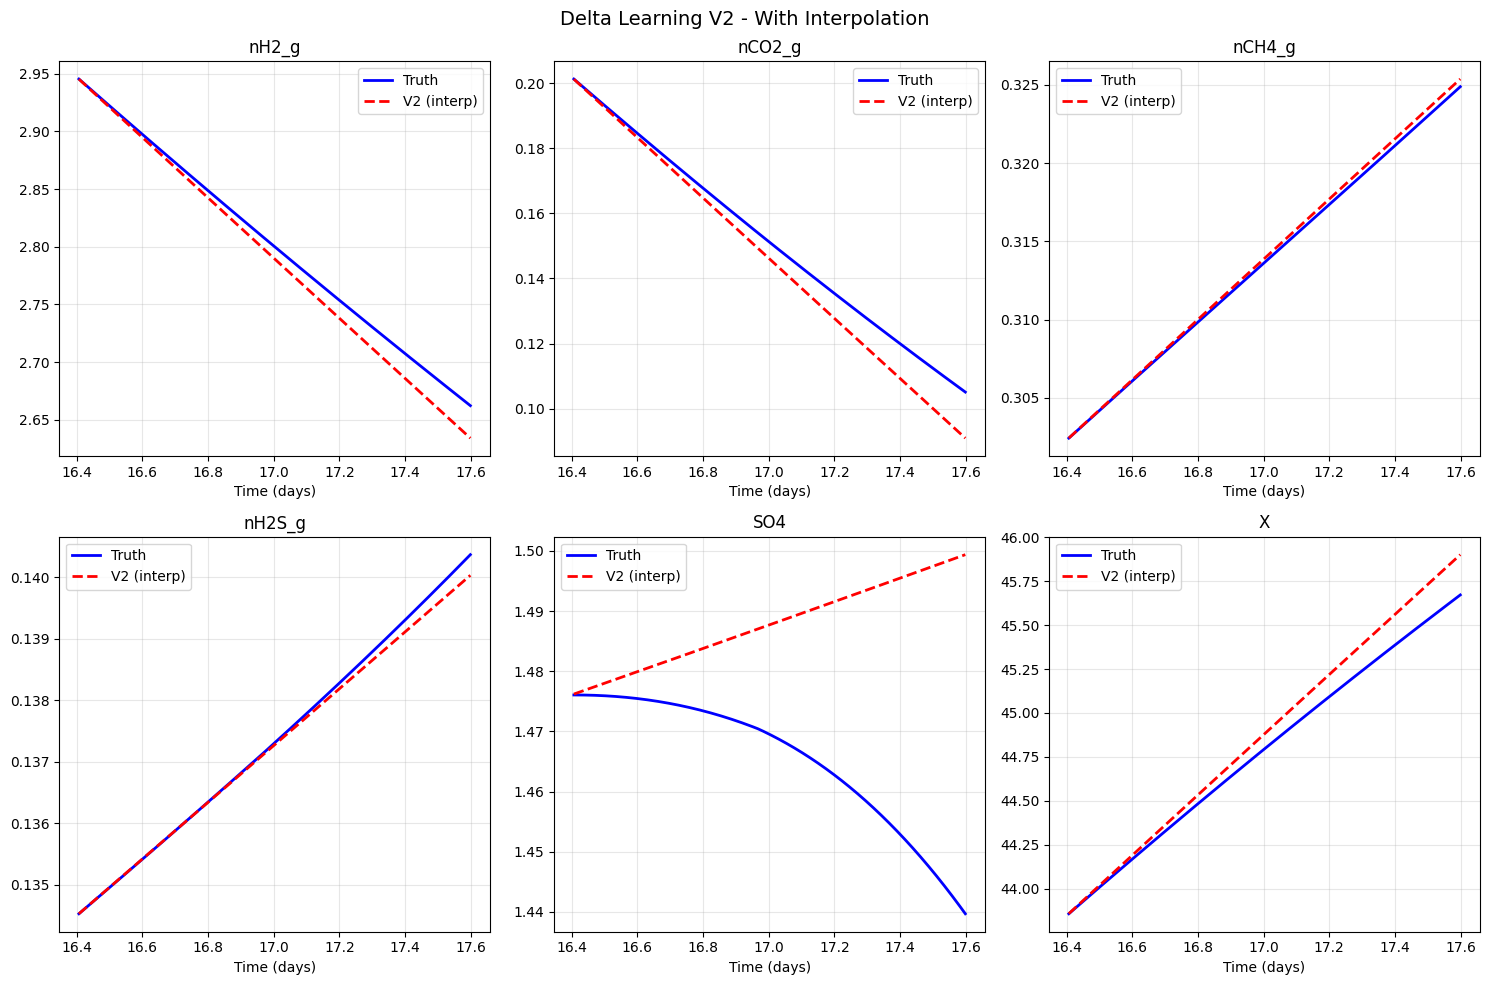

In [20]:
# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
vars_plot = [(0, 'nH2_g'), (1, 'nCO2_g'), (2, 'nCH4_g'), (3, 'nH2S_g'), (6, 'SO4'), (8, 'X')]

for ax, (idx, name) in zip(axes.flat, vars_plot):
    ax.plot(t_fc, gt[:, idx], 'b-', lw=2, label='Truth')
    ax.plot(t_fc, preds_final[:, idx], 'r--', lw=2, label='V2 (interp)')
    ax.set_xlabel('Time (days)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Delta Learning V2 - With Interpolation', fontsize=14)
plt.tight_layout()
plt.show()

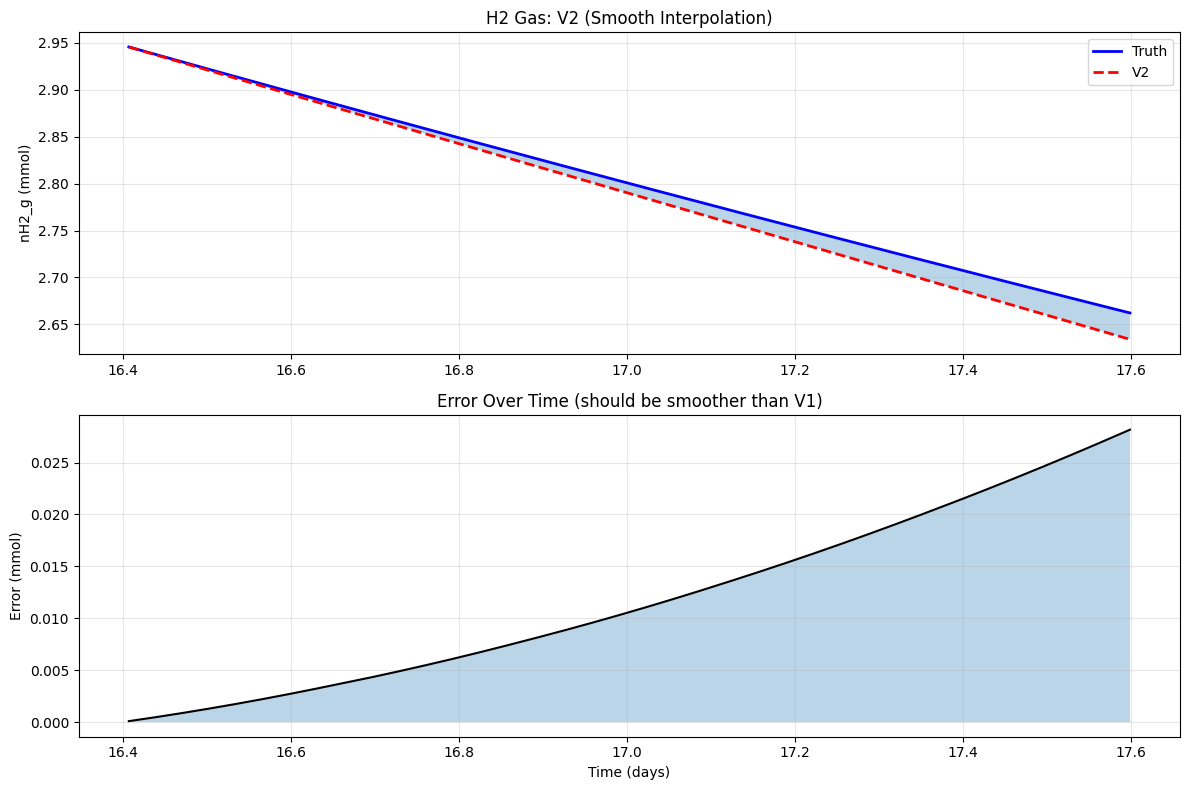

In [15]:
# H2 detailed
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(t_fc, gt[:, 0], 'b-', lw=2, label='Truth')
ax1.plot(t_fc, preds_final[:, 0], 'r--', lw=2, label='V2')
ax1.fill_between(t_fc, gt[:, 0], preds_final[:, 0], alpha=0.3)
ax1.set_ylabel('nH2_g (mmol)')
ax1.set_title('H2 Gas: V2 (Smooth Interpolation)')
ax1.legend()
ax1.grid(True, alpha=0.3)

err = np.abs(preds_final[:, 0] - gt[:, 0])
ax2.plot(t_fc, err, 'k-')
ax2.fill_between(t_fc, 0, err, alpha=0.3)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Error (mmol)')
ax2.set_title('Error Over Time (should be smoother than V1)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Save
os.makedirs('results', exist_ok=True)
torch.save(model.state_dict(), 'results/delta_lstm_v2.pt')
with open('results/scalers_v2.pkl', 'wb') as f:
    pickle.dump({'feat': feat_scaler, 'delta': delta_scaler}, f)
print("Saved model and scalers")